Tratamento e Visualização De Dados - UV-Vis
===

**Autor:** [Mateus de Jesus Mendes](mailto:mateus25032@ilum.cnpem.br)

##### **Funções**

Importação das bibliotecas:

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

Plot singular:

In [8]:
def uvvis_plot(file_path=None, sample_name=None):
    """
    Gera plots (Matplotlib e Plotly) de um único espectro UV-Vis.

    ### Parâmetros

    - file_path (str): Caminho do arquivo contendo dados de espectroscopia UV-Vis.
    - sample_name (str): Nome da amostra.
    """

    data = []
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        start_reading = False
        for line in f:
            line = line.strip()
            if not line:
                continue
            
            if line.startswith("Wavelength"): # Detecta início dos dados
                start_reading = True
                continue
            if start_reading:
                parts = line.split(",")
                if len(parts) >= 2:
                    try:
                        x, y = map(float, parts[:2])
                        data.append((x, y))
                    except:
                        continue

    df = pd.DataFrame(data, columns=["Wavelength", "Absorbance"])

    # Matplotlib
    plt.figure(figsize=(6.3, 4.2), dpi=300)
    plt.plot(df["Wavelength"], df["Absorbance"], linewidth=1.3)
    plt.xlabel("Comprimento de onda (nm)")
    plt.ylabel("Absorbância (u.a.)")
    plt.title(f"Espectro UV-Vis — {sample_name}")
    plt.tight_layout()
    plt.show()

    # Plotly
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=df["Wavelength"],
        y=df["Absorbance"],
        mode="lines",
        line=dict(width=1.3, color="royalblue"),
        name="UV-Vis"
    ))

    fig.update_layout(
        title=f"Espectro UV-Vis — {sample_name}",
        xaxis=dict(title="Comprimento de onda (nm)"),
        yaxis=dict(title="Absorbância (u.a.)"),
        template="simple_white",
        width=800,
        height=500
    )

    fig.show()

Plot conjunto (*overlayed*):

In [9]:
def uvvis_overlayed(file_paths=None, sample_names=None):
    """
    Gera plots (Matplotlib e Plotly) de múltiplos espectros UV-Vis em overlay.

    ### Parâmetros

    - file_paths (list of str): Lista de caminhos dos arquivos contendo dados de espectroscopia UV-Vis.
    - sample_names (list of str, optional): Nomes das amostras.
    """

    if sample_names is None:
        sample_names = [f"Amostra {i+1}" for i in range(len(file_paths))]

    # Matplotlib
    plt.figure(figsize=(6.3, 4.2), dpi=300)
    for path, name in zip(file_paths, sample_names):
        data = []
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            start_reading = False
            for line in f:
                line = line.strip()
                if not line:
                    continue
                if line.startswith("Wavelength"):
                    start_reading = True
                    continue
                if start_reading:
                    parts = line.split(",")
                    if len(parts) >= 2:
                        try:
                            x, y = map(float, parts[:2])
                            data.append((x, y))
                        except:
                            continue
        df = pd.DataFrame(data, columns=["Wavelength_nm", "Absorbance"])
        plt.plot(df["Wavelength_nm"], df["Absorbance"], lw=1.2, label=name)
    
    plt.xlabel("Comprimento de onda (nm)")
    plt.ylabel("Absorbância (u.a.)")
    plt.title("Espectros UV-Vis sobrepostos")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plotly
    fig = go.Figure()
    for path, name in zip(file_paths, sample_names):
        data = []
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            start_reading = False
            for line in f:
                line = line.strip()
                if not line:
                    continue
                if line.startswith("Wavelength"):
                    start_reading = True
                    continue
                if start_reading:
                    parts = line.split(",")
                    if len(parts) >= 2:
                        try:
                            x, y = map(float, parts[:2])
                            data.append((x, y))
                        except:
                            continue
        df = pd.DataFrame(data, columns=["Wavelength_nm", "Absorbance"])
        fig.add_trace(go.Scatter(
            x=df["Wavelength_nm"],
            y=df["Absorbance"],
            mode="lines",
            name=name
        ))

    fig.update_layout(
        title="Espectros UV-Vis sobrepostos",
        xaxis=dict(title="Comprimento de onda (nm)"),
        yaxis=dict(title="Absorbância (u.a.)"),
        template="simple_white",
        width=800,
        height=500
    )
    fig.show()


# UV-Vis - GO

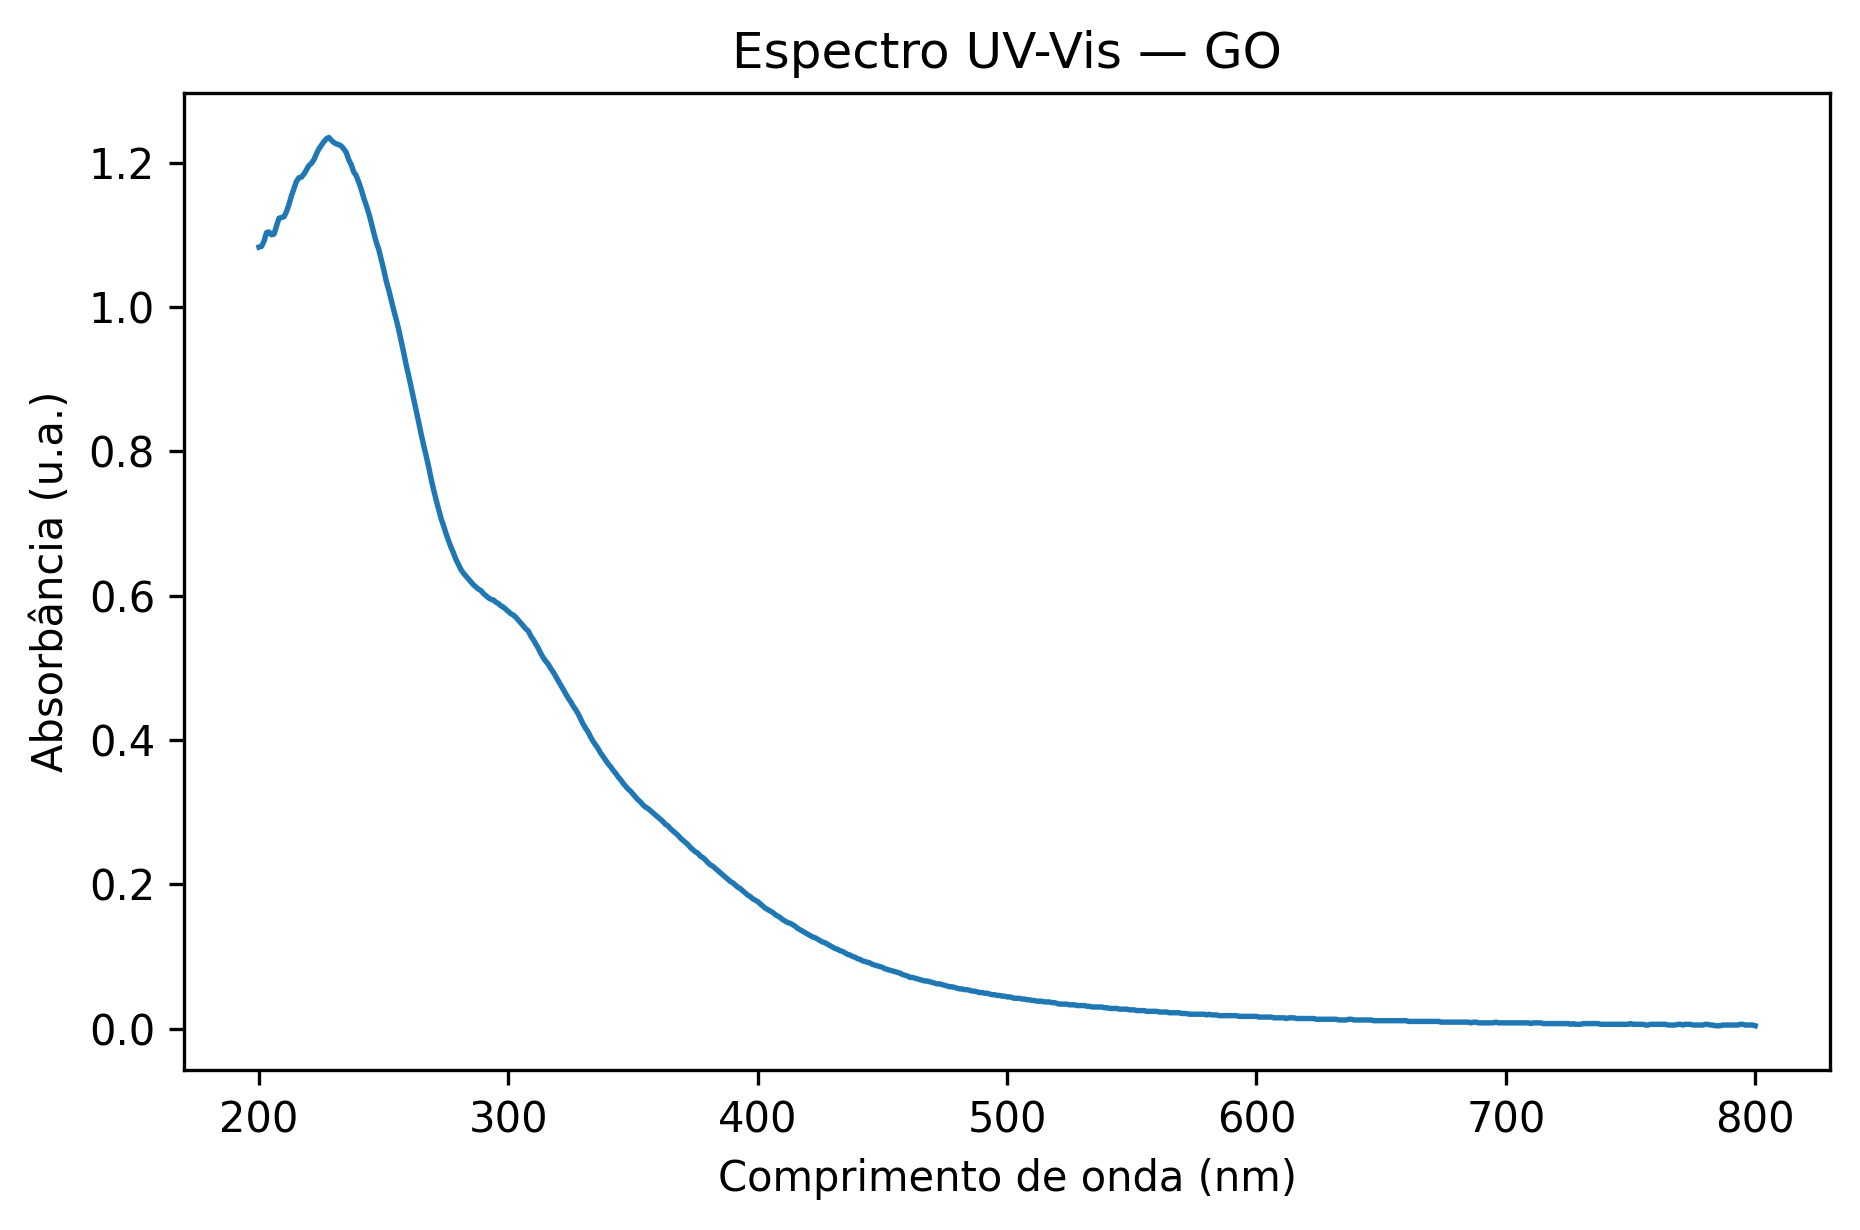

In [10]:
uvvis_plot('GO_MMV.txt', 'GO')

# UV-Vis - rGO

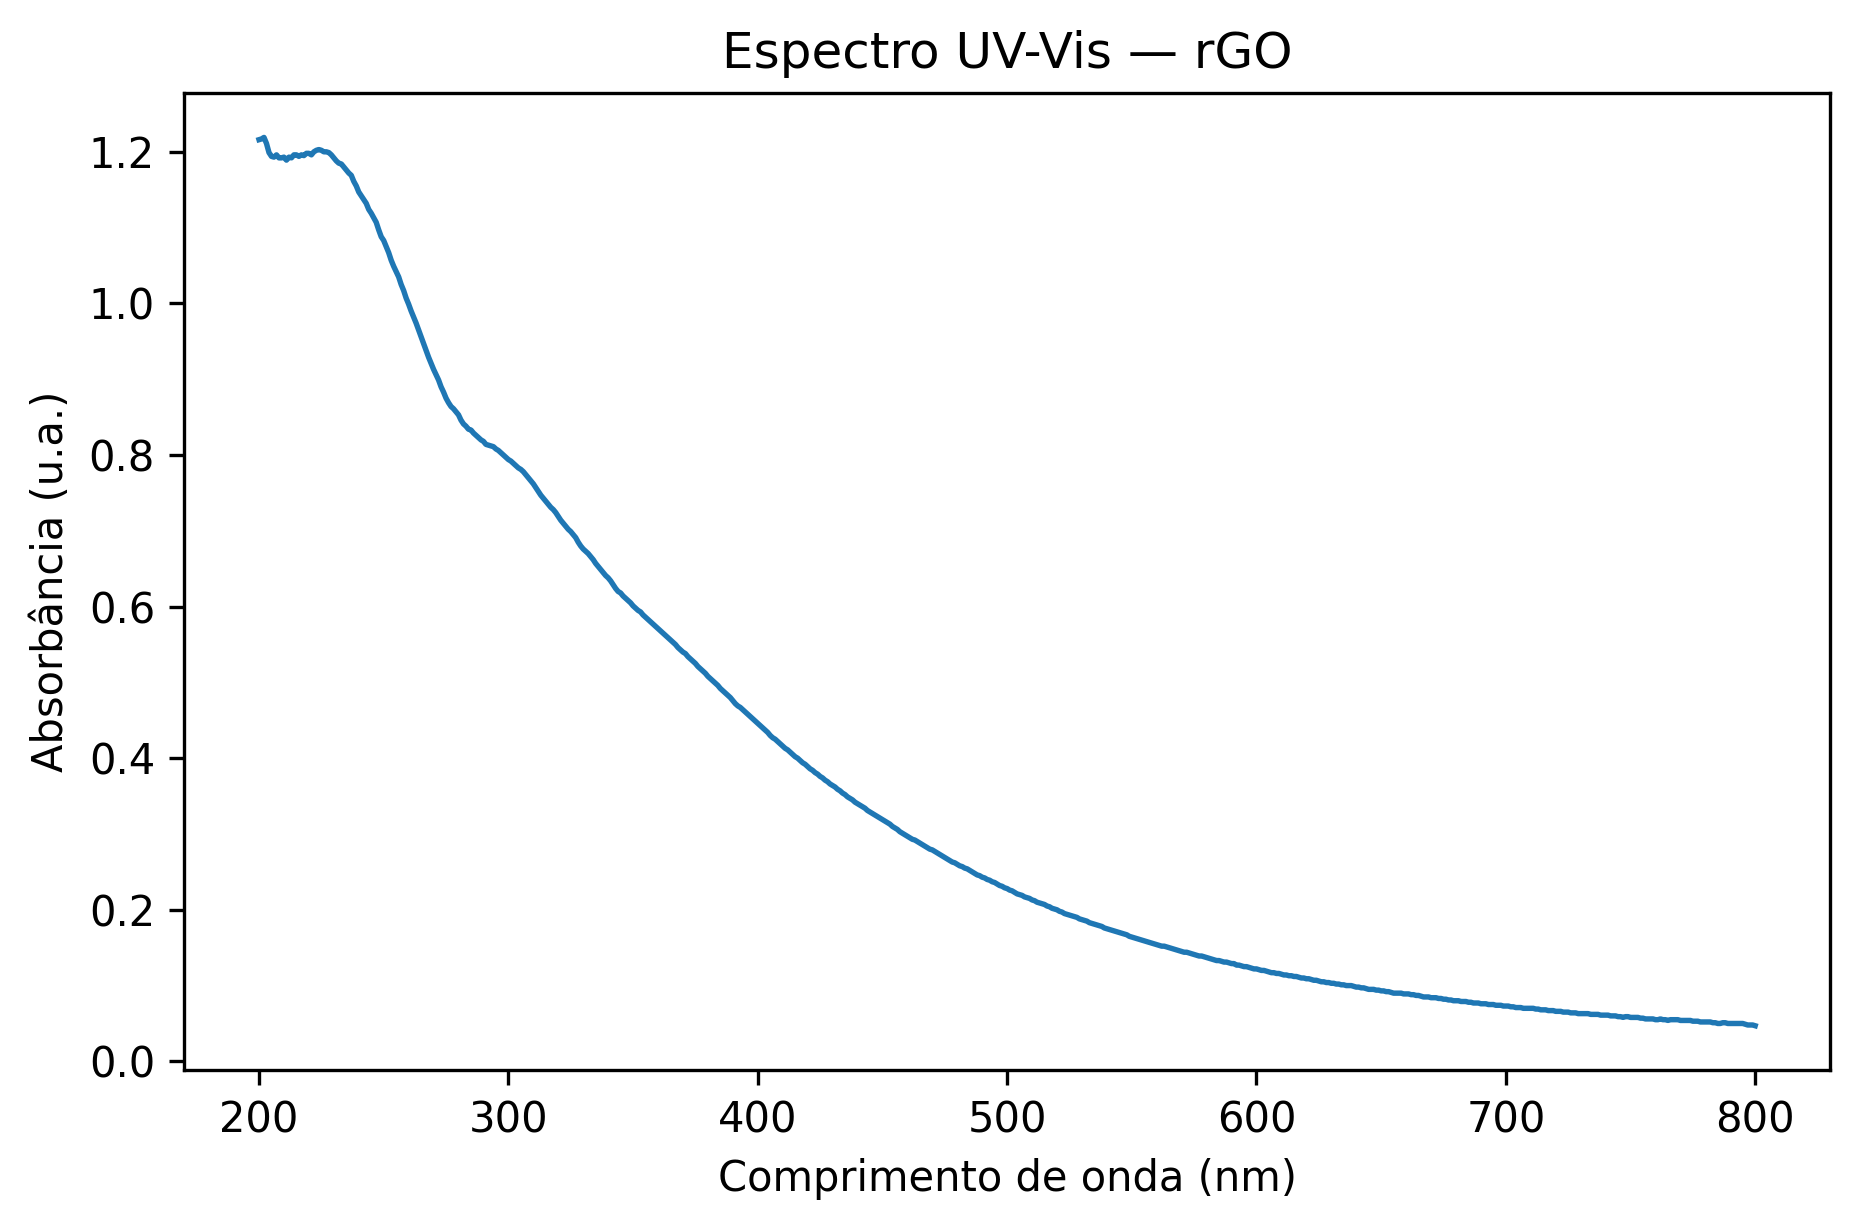

In [11]:
uvvis_plot('rGO_MMV.txt', 'rGO')

# *Overlay*

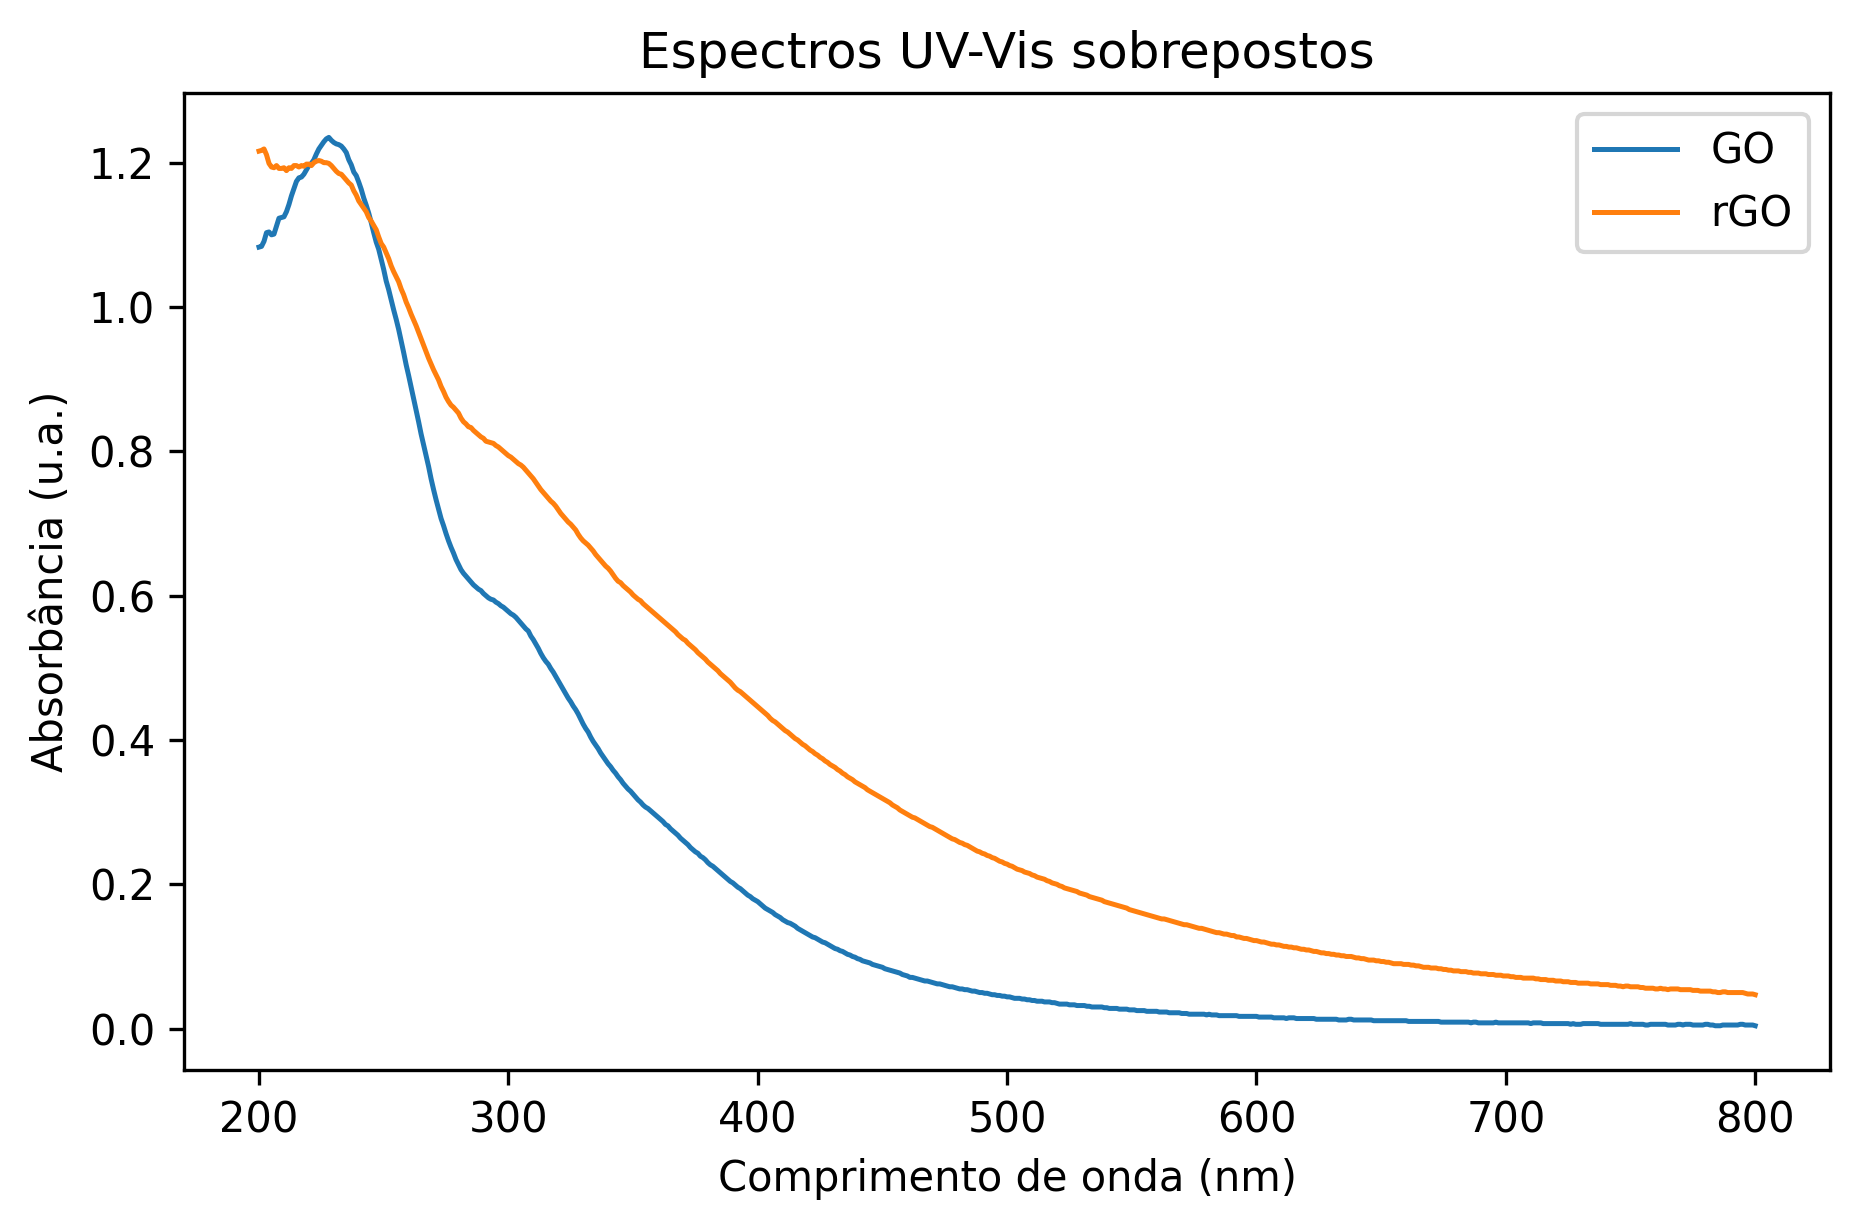

In [12]:
uvvis_overlayed(['GO_MMV.txt', 'rGO_MMV.txt'], ['GO', 'rGO'])